# DLAM Alignment Evaluation

Publication-oriented single-subject diagnostics for the deterministic latent alignment model. This notebook mirrors the older `notebooks/single_subject_dlam_alignment.ipynb` workflow, but makes the DLAM variant explicit and adds full-brain post-alignment views plus nilearn/yabplot on-brain rendering.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
candidates = [cwd, cwd / 'gtex_gp', cwd.parent, cwd.parent / 'gtex_gp']
REPO_ROOT = next((p for p in candidates if (p / 'src').exists() and (p / 'eval_gxp_onbrain_views.ipynb').exists()), cwd)
%cd {REPO_ROOT}
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.eval_utils.results_eda as results_eda
import src.eval_utils.dlam_diagnostics as dlam_diag
import src.eval_utils.eval_dlam_alignment as align_viz

from src.eval_utils.results_eda import (
    prepare_pre_post_harmonization,
    plot_single_subject_scatter_triplet,
    plot_subject_prepost_heatmaps,
)
from src.eval_utils.dlam_diagnostics import (
    DlamDiagnosticsConfig,
    compute_dlam_loro_fold_metrics,
    diagnostics_summary_table,
    fit_dlam_subject_diagnostics,
    plot_subject_ahba_harmonized_heatmaps,
    set_academic_style,
)
from src.eval_utils.eval_dlam_alignment import (
    EDAConfig,
    cache_run_settings,
    plot_coordinate_alignment_component,
    render_nilearn_alignment_components,
    select_subject_for_alignment,
)

set_academic_style()
print('repo:', REPO_ROOT)
print('dlam diagnostics:', dlam_diag.__file__)
print('alignment viz:', align_viz.__file__)

/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp
repo: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp
dlam diagnostics: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/dlam_diagnostics.py
alignment viz: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_dlam_alignment.py


## Reload Helpers


In [2]:
# Re-run this cell after editing src/eval_utils/*.py; no kernel restart needed.
importlib.reload(results_eda)
importlib.reload(dlam_diag)
importlib.reload(align_viz)

from src.eval_utils.results_eda import (
    prepare_pre_post_harmonization,
    plot_single_subject_scatter_triplet,
    plot_subject_prepost_heatmaps,
)
from src.eval_utils.dlam_diagnostics import (
    DlamDiagnosticsConfig,
    compute_dlam_loro_fold_metrics,
    diagnostics_summary_table,
    fit_dlam_subject_diagnostics,
    plot_subject_ahba_harmonized_heatmaps,
    set_academic_style,
)
from src.eval_utils.eval_dlam_alignment import (
    EDAConfig,
    cache_run_settings,
    plot_coordinate_alignment_component,
    render_nilearn_alignment_components,
    select_subject_for_alignment,
)

set_academic_style()
print('reloaded:', dlam_diag.__file__)
print('reloaded:', align_viz.__file__)


reloaded: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/dlam_diagnostics.py
reloaded: /scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_dlam_alignment.py


## 2. Controls

Edit only this cell for normal use. The defaults target the constrained-anchor model with distance shrinkage toward AHBA.

In [3]:
CSV_PATH = 'data/raw/gxp_samples.csv'
HVG_PATH = 'data/metadata/gene_lists/ahba_100hvg.txt'
CACHE_ROOT = 'out/loro_subject_cache_cv_shrink'
GENE_SCOPE = 'allgenes'
CACHE_CONFIG_MODEL = 'dlam'  # source of run-policy/model settings scraped from cache JSON

MODEL_NAME = 'dlam'
# DLAM settings below are filled from CACHE_CONFIG_MODEL unless explicitly changed after the config cell.

SUBJECT_MODE = 'median'   # median | best | worst, ranked from cache metrics
SUBJECT_ID = None         # set an explicit GTEx id to override SUBJECT_MODE
REQUIRE_N_OBSERVED = 12  # set None to select from all eligible subjects
RUN_LORO = False
HOLD_SELECTOR = 'median_rmse'
HOLD_PARCEL = None
USE_DIAGNOSTICS_CACHE = True
WRITE_DIAGNOSTICS_CACHE = True
FORCE_REFIT_DIAGNOSTICS = False

AXIS_X = 'y'
AXIS_Y = 'z'
COMPONENTS = [0, 1, 2]
LATENT_SPACE = 'spatial'  # spatial | expression

ONBRAIN_COMPONENT = 0
ONBRAIN_CMAP = 'auto'  # LV1=cividis, LV2=plasma, LV3=viridis
ONBRAIN_CLIM_PCT = (2.0, 98.0)
NILEARN_NODE_SIZE = 72
NILEARN_MATCHED_NODE_SIZE = 135
RENDER_YABPLOT = False
YABPLOT_SCOPES = ['cortical', 'subcortical_cerebellar']
YABPLOT_ZOOM = 1.25
EXPORT_DIR = None  # e.g. 'out/dlam_alignment_renders' or None


## 3. Build Configuration

In [4]:
EDA_BASE_CFG = EDAConfig(
    csv_path=CSV_PATH,
    cache_root=CACHE_ROOT,
    gene_scope=GENE_SCOPE,
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam',
)
CACHE_RUN = cache_run_settings(EDA_BASE_CFG, model=CACHE_CONFIG_MODEL)

EDA_CFG = EDAConfig(
    csv_path=str(CACHE_RUN.get('csv_path', CSV_PATH)),
    cache_root=CACHE_ROOT,
    gene_scope=str(CACHE_RUN.get('gene_scope', GENE_SCOPE)),
    min_observed_parcels=int(CACHE_RUN.get('min_observed_parcels', EDA_BASE_CFG.min_observed_parcels)),
    combat_use_covariates=bool(CACHE_RUN.get('combat_use_covariates', EDA_BASE_CFG.combat_use_covariates)),
    drop_macro_system_covariate=bool(CACHE_RUN.get('drop_macro_system_covariate', EDA_BASE_CFG.drop_macro_system_covariate)),
    gtex_rep_mode=str(CACHE_RUN.get('gtex_rep_mode', EDA_BASE_CFG.gtex_rep_mode)),
    gtex_hemi_mode=str(CACHE_RUN.get('gtex_hemi_mode', EDA_BASE_CFG.gtex_hemi_mode)),
    matching_policy=str(CACHE_RUN.get('matching_policy', 'centroids_and_volumes')),
    matching_policy_hemi_mode=str(CACHE_RUN.get('matching_policy_hemi_mode', 'force_left')),
    collapse_cerebellum=bool(CACHE_RUN.get('collapse_cerebellum', False)),
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam',
)

DLAM_CFG = DlamDiagnosticsConfig(
    csv_path=EDA_CFG.csv_path,
    hvg_path=str(CACHE_RUN.get('hvg_path', HVG_PATH)),
    cache_root=EDA_CFG.cache_root,
    gene_scope=EDA_CFG.gene_scope,
    min_observed_parcels=EDA_CFG.min_observed_parcels,
    combat_use_covariates=EDA_CFG.combat_use_covariates,
    drop_macro_system_covariate=EDA_CFG.drop_macro_system_covariate,
    atlas_agg=str(CACHE_RUN.get('atlas_agg', 'mean')),
    gtex_rep_mode=EDA_CFG.gtex_rep_mode,
    gtex_hemi_mode=EDA_CFG.gtex_hemi_mode,
    matching_policy=EDA_CFG.matching_policy,
    matching_policy_hemi_mode=EDA_CFG.matching_policy_hemi_mode,
    collapse_cerebellum=bool(EDA_CFG.collapse_cerebellum),
    dlam_cache_dirname=EDA_CFG.dlam_cache_dirname,
    n_comp_target=int(CACHE_RUN.get('n_comp_target', DlamDiagnosticsConfig.n_comp_target)),
    ridge_alpha_bridge=float(CACHE_RUN.get('ridge_alpha_bridge', DlamDiagnosticsConfig.ridge_alpha_bridge)),
    rbf_smoothing=float(CACHE_RUN.get('rbf_smoothing', DlamDiagnosticsConfig.rbf_smoothing)),
    gp_length_scale=float(CACHE_RUN.get('gp_length_scale', DlamDiagnosticsConfig.gp_length_scale)),
    seed=int(CACHE_RUN.get('seed', DlamDiagnosticsConfig.seed)),
    c_min=int(CACHE_RUN.get('c_min', DlamDiagnosticsConfig.c_min)),
    strategy=str(CACHE_RUN.get('strategy', DlamDiagnosticsConfig.strategy)),
    spatial_method=str(CACHE_RUN.get('spatial_method', DlamDiagnosticsConfig.spatial_method)),
    anchor_distance_shrink=bool(CACHE_RUN.get('anchor_distance_shrink', DlamDiagnosticsConfig.anchor_distance_shrink)),
    anchor_distance_d0=float(CACHE_RUN.get('anchor_distance_d0', DlamDiagnosticsConfig.anchor_distance_d0)),
    anchor_distance_tau=float(CACHE_RUN.get('anchor_distance_tau', DlamDiagnosticsConfig.anchor_distance_tau)),
)
DLAM_CFG.use_diagnostics_cache = bool(USE_DIAGNOSTICS_CACHE) and not FORCE_REFIT_DIAGNOSTICS
DLAM_CFG.write_diagnostics_cache = bool(WRITE_DIAGNOSTICS_CACHE)
print(f"diagnostics cache: read={DLAM_CFG.use_diagnostics_cache} write={DLAM_CFG.write_diagnostics_cache} force_refit={FORCE_REFIT_DIAGNOSTICS}")
print('scraped cache config from:', CACHE_ROOT, '/', EDA_CFG.gene_scope, '/', CACHE_CONFIG_MODEL)

subject_id = SUBJECT_ID or select_subject_for_alignment(
    EDA_CFG,
    model=MODEL_NAME,
    mode=SUBJECT_MODE,
    metric='pearson_r',
    require_n_observed=REQUIRE_N_OBSERVED,
)
print('subject:', subject_id)
print('cache root:', EDA_CFG.cache_root)
display(pd.Series(CACHE_RUN, name='scraped_cache_run'))
display(pd.Series(DLAM_CFG.__dict__, name='dlam_config'))


diagnostics cache: read=True write=True force_refit=False
scraped cache config from: out/loro_subject_cache_cv_shrink / allgenes / dlam


selected GTEX-1H3O1 from n=33 subjects with coverage=12; pearson_r=0.9657
subject: GTEX-1H3O1
cache root: out/loro_subject_cache_cv_shrink


csv_path                                       data/raw/gxp_samples.csv
hvg_path                       data/metadata/gene_lists/ahba_100hvg.txt
gene_scope                                                     allgenes
min_observed_parcels                                                  5
combat_use_covariates                                              True
drop_macro_system_covariate                                       False
atlas_agg                                                          mean
gtex_rep_mode                                                  centroid
gtex_hemi_mode                                              mirror_left
matching_policy                                   centroids_and_volumes
matching_policy_hemi_mode                                    force_left
collapse_cerebellum                                               False
n_comp_target                                                         3
ridge_alpha_bridge                                              

csv_path                                       data/raw/gxp_samples.csv
hvg_path                       data/metadata/gene_lists/ahba_100hvg.txt
cache_root                             out/loro_subject_cache_cv_shrink
gene_scope                                                     allgenes
min_observed_parcels                                                  5
combat_use_covariates                                              True
drop_macro_system_covariate                                       False
atlas_agg                                                          mean
gtex_rep_mode                                                  centroid
gtex_hemi_mode                                              mirror_left
matching_policy                                   centroids_and_volumes
matching_policy_hemi_mode                                    force_left
collapse_cerebellum                                               False
dlam_cache_dirname                                              

## 4. Harmonization and Standard Single-Subject Views

In [5]:
# PREPOST = prepare_pre_post_harmonization(EDA_CFG)
# print('eligible subjects:', len(PREPOST['subjects']))

# fig, axes = plot_subject_prepost_heatmaps(
#     PREPOST,
#     subject_id=subject_id,
#     gene_mode='hvg',
#     observed_only=True,
#     label_mode='gtex',
#     label_stride=1,
# )

# fig, axes, sid = plot_single_subject_scatter_triplet(
#     EDA_CFG,
#     subject_id=subject_id,
#     rank_model=MODEL_NAME,
#     color_by='parcel',
#     top_n=10,
# )
# print('scatter subject:', sid)

## 5. Fit DLAM Alignment Diagnostics

In [6]:
if RUN_LORO:
    fold_df = compute_dlam_loro_fold_metrics(DLAM_CFG, subject_id)
    display(fold_df)
    diag = fit_dlam_subject_diagnostics(
        DLAM_CFG,
        subject_id=subject_id,
        fold_mode='loro',
        hold_parcel=HOLD_PARCEL,
        hold_selector=HOLD_SELECTOR,
    )
else:
    diag = fit_dlam_subject_diagnostics(
        DLAM_CFG,
        subject_id=subject_id,
        fold_mode='full',
    )

display(diagnostics_summary_table(diag))
print('observed parcels:', len(diag.obs_idx_all), '| train parcels:', len(diag.train_idx), '| components:', diag.n_comp)

,subject,fold_mode,hold_parcel,fold_selector,n_obs,n_train,n_comp,basis_model,hold_pearson,hold_rmse,hold_n_points
0,GTEX-1H3O1,full,-1,,12,12,3,affine_gl3,NaN,NaN,0


observed parcels: 12 | train parcels: 12 | components: 3


## 6. Publication Alignment Panels

These panels retain the original diagnostic intent: pre-aligned subject scores, post-aligned scores, and AHBA reference scores. The added fourth map shows the model-imputed full-brain post-aligned score field.

In [7]:
# for component in COMPONENTS:
#     if component < diag.n_comp:
#         plot_coordinate_alignment_component(
#             diag,
#             component=component,
#             latent_space=LATENT_SPACE,
#             axis_x=AXIS_X,
#             axis_y=AXIS_Y,
#             cmap=ONBRAIN_CMAP,
#             undo_force_left_for_display=True,
#         )

## 7. On-Brain Alignment Views

The main figure shows observed GTEx LV scores before/after alignment, two AHBA reference brain views, and the matched-parcel score scatters. AHBA matched parcels are ring-highlighted.

rendered 3 nilearn alignment component figure(s)


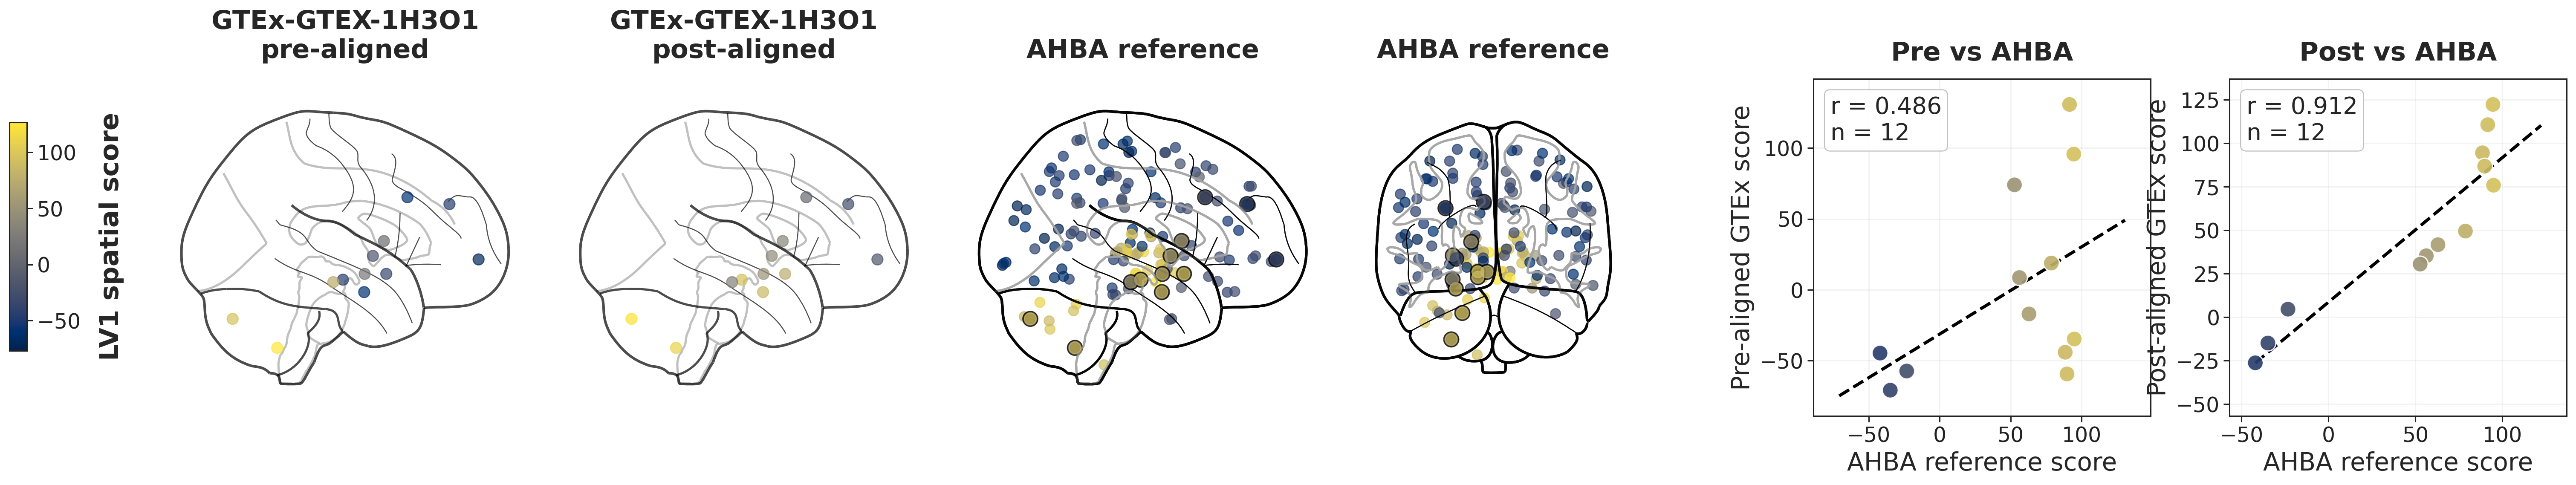

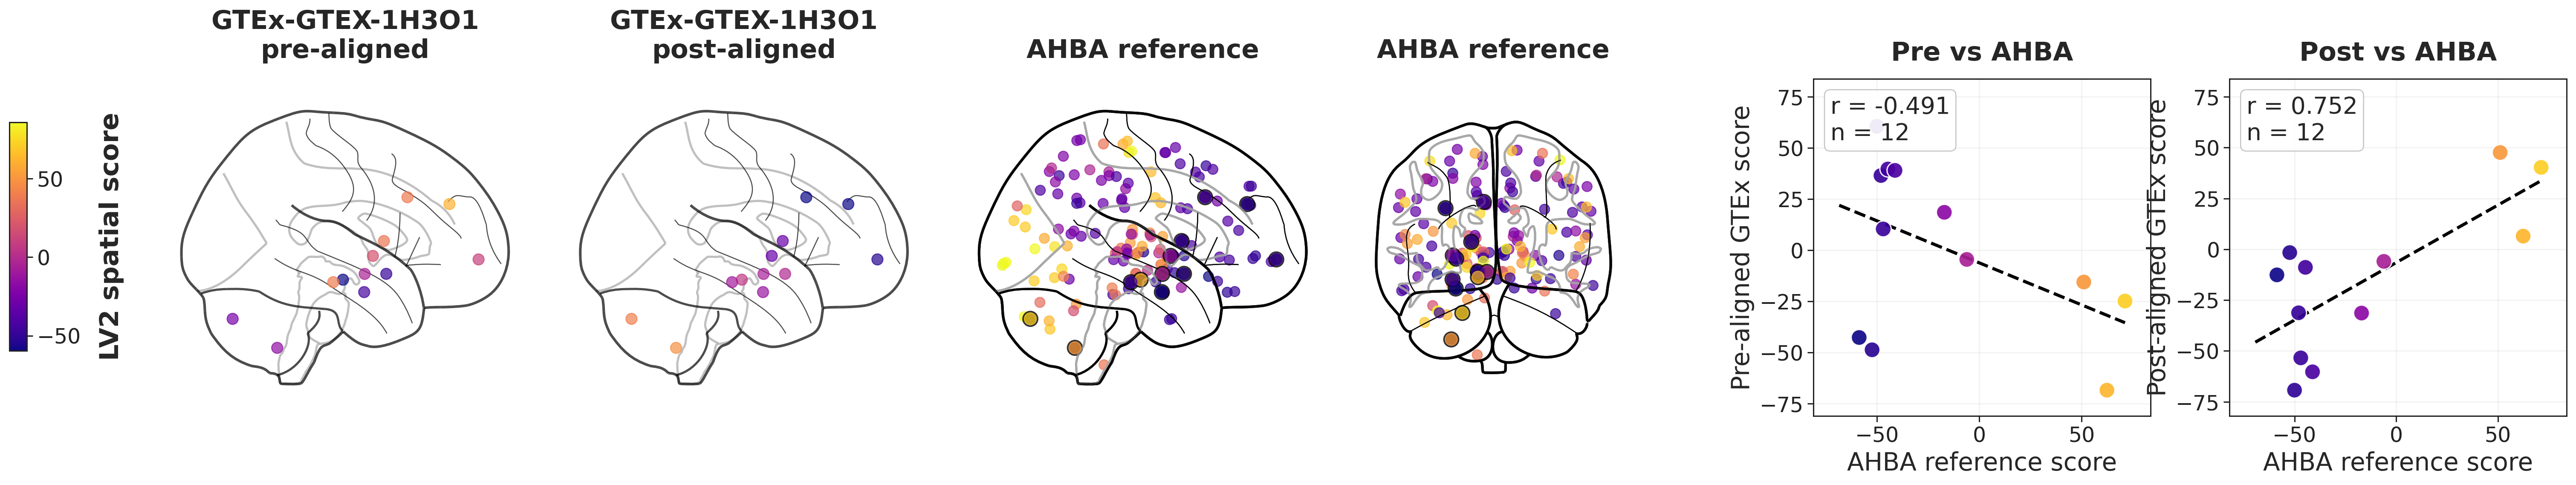

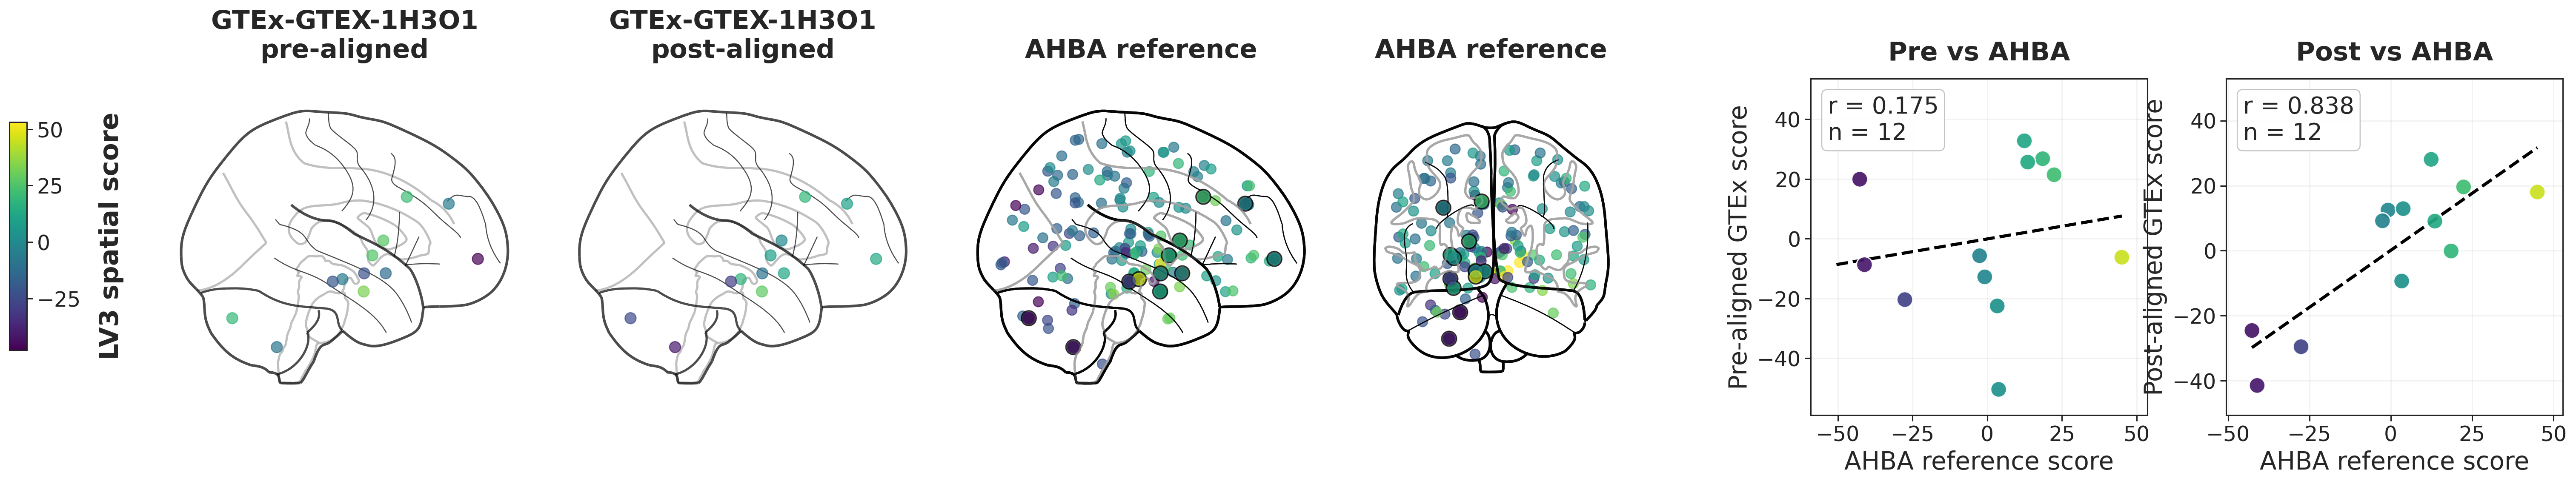

In [8]:
rendered = render_nilearn_alignment_components(
    diag,
    components=COMPONENTS,
    latent_space=LATENT_SPACE,
    cmap=ONBRAIN_CMAP,
    clim_pct=ONBRAIN_CLIM_PCT,
    node_size=NILEARN_NODE_SIZE,
    matched_node_size=NILEARN_MATCHED_NODE_SIZE,
    undo_force_left_for_display=True,
)
print(f'rendered {len(rendered)} nilearn alignment component figure(s)')

## 9. Harmonized Expression Heatmaps

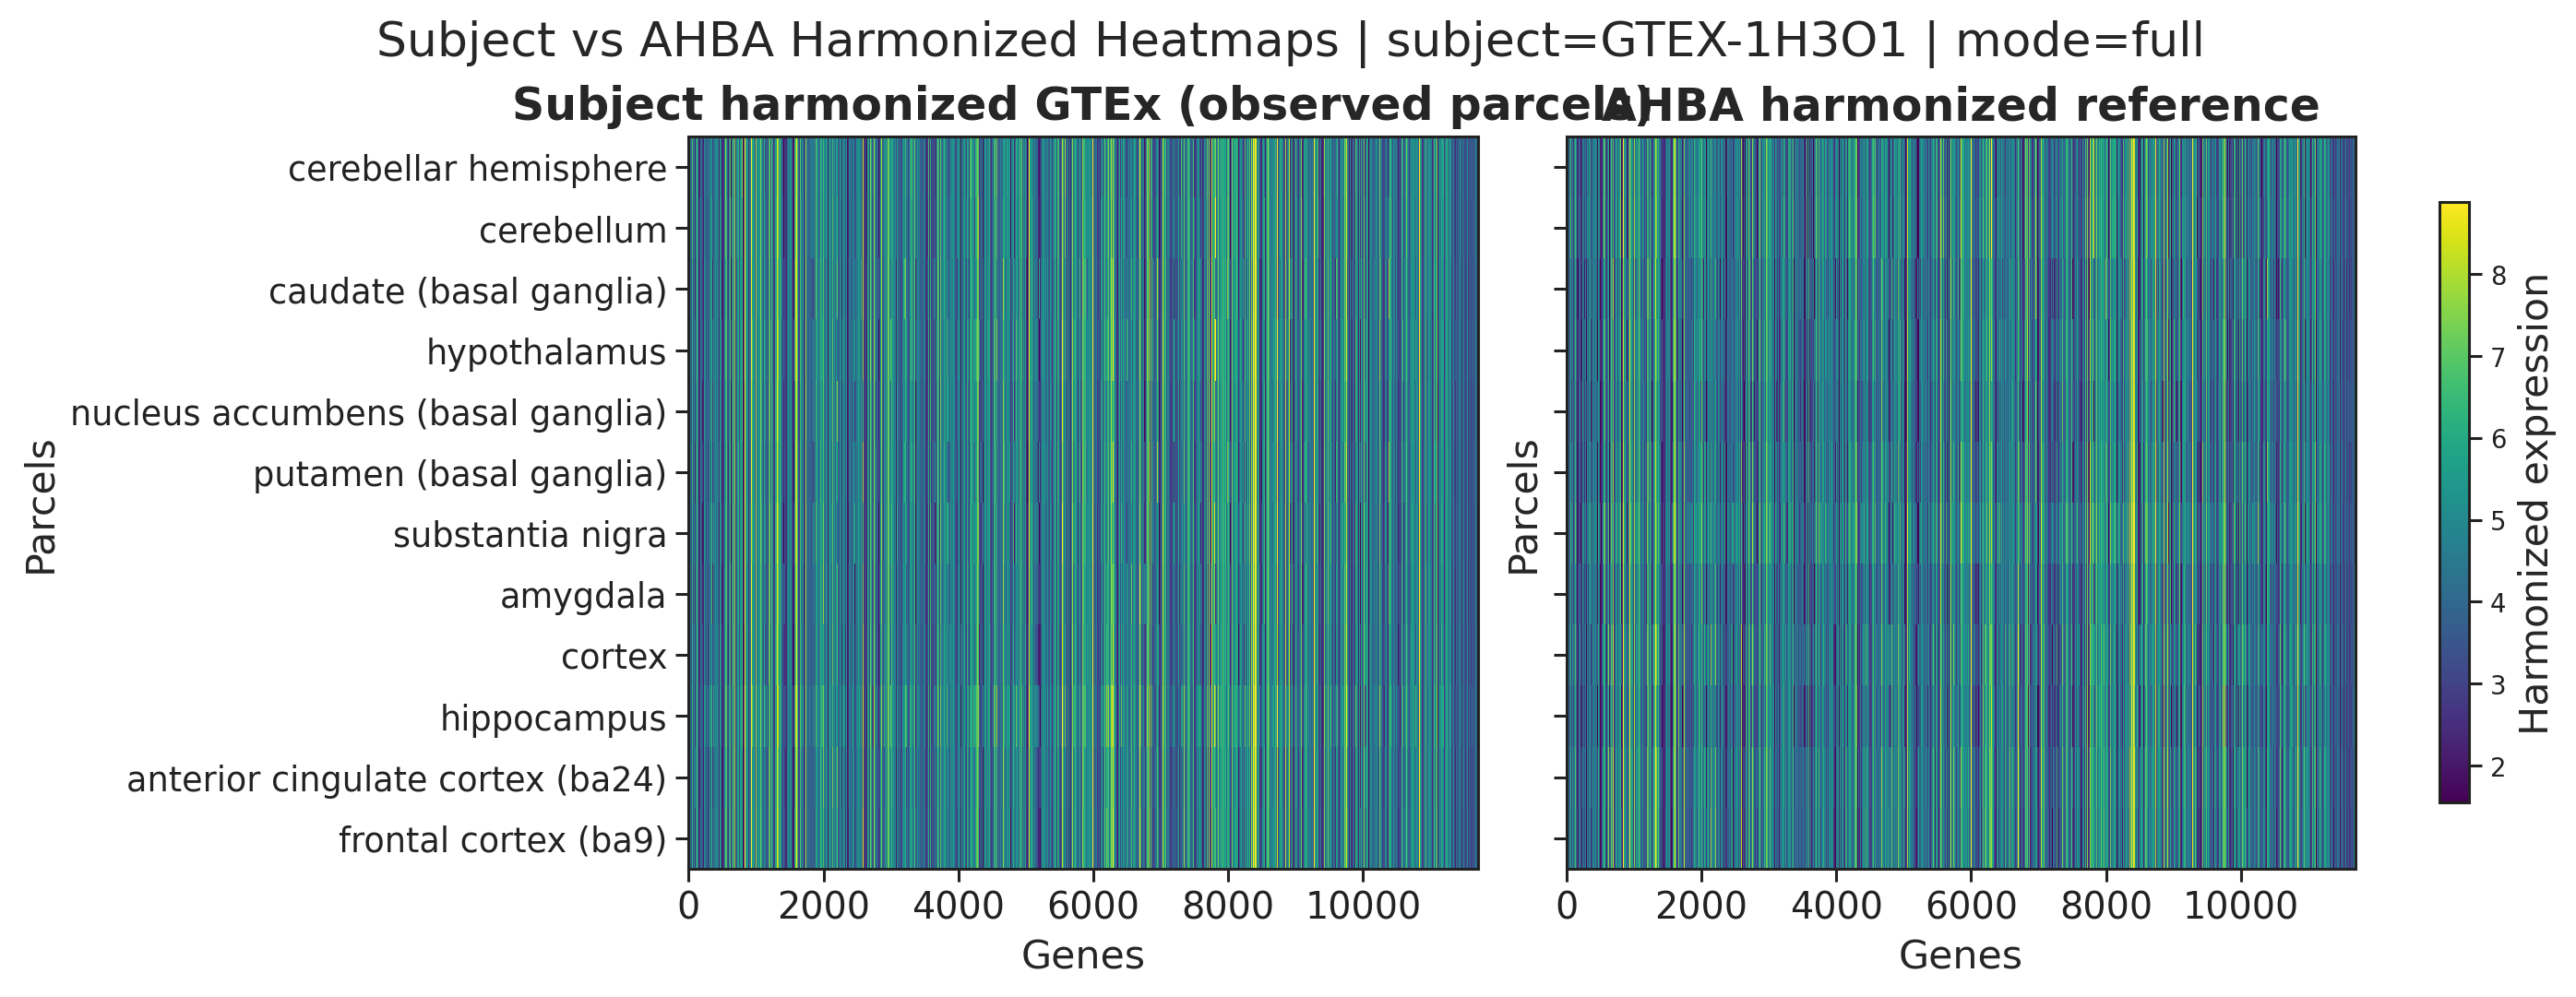

In [9]:
fig, axes = plot_subject_ahba_harmonized_heatmaps(
    diag,
    observed_only=True,
    label_mode='gtex',
    label_stride=1,
)